In [1]:
import requests
import os
from dotenv import load_dotenv
from pprint import pprint
import pandas as pd
import json

# .env 파일에서 환경 변수 로드
load_dotenv()

# 환경 변수에서 값 읽기
client_id = os.getenv("CLIENT_ID")  # .env 파일의 NAVER_CLIENT_ID
client_secret = os.getenv("CLIENT_SECRET")  # .env 파일의 NAVER_CLIENT_SECRET
print(client_id[:4])
print(client_secret[:4])

headers = {
    'X-NCP-APIGW-API-KEY-ID': client_id,
    'X-NCP-APIGW-API-KEY': client_secret,
}

ic0k
An89


In [2]:
def search_local(query, display=100): 
    # query string 문자열을 dict 선언
    payload = {
        'query': query,
        'display': display,
        'sort': 'sim'
    }

    DOMAIN_URL = 'https://naverapihub.apigw.ntruss.com'

    url = f'{DOMAIN_URL}/search/v1/news'
    print(url)

    # requests get(url, params, headers) 요청 
    res = requests.get(url, params=payload, headers=headers)
    # json() 함수로 응답 결과 가져오기
    items_data = res.json()['items']
    print(len(items_data))
    
    return items_data  #[{},{}]

def save_json(items_data):
    with open('../data/news.json','w',encoding='utf-8') as file:
        json.dump(items_data, file)


if __name__ == '__main__':
    save_json(search_local('부동산', display=100))

https://naverapihub.apigw.ntruss.com/search/v1/news
100


In [3]:
import time

def search_news_all(query, total=500, display=100):
    DOMAIN_URL = 'https://naverapihub.apigw.ntruss.com'
    url = f'{DOMAIN_URL}/search/v1/news'
    all_items = []

    for start in range(1, total + 1, display):   # 1, 101, 201, 301, 401
        payload = {
            'query': query,
            'display': display,
            'start': start,
            'sort': 'sim'
        }
        res = requests.get(url, params=payload, headers=headers)
        data = res.json()

        items = data.get('items', [])
        if not items:          # 더 이상 결과가 없으면 중단
            break
        all_items.extend(items)

        time.sleep(0.1)        # 호출 간 간격 (API 부하/제한 대비)

    return all_items          # 최대 500개


if __name__ == '__main__':
    items = search_news_all('부동산', total=500, display=100)
    print(len(items))
    save_json(items)

500


In [4]:
import pandas as pd

news_df = pd.read_json('../data/news.json')
print(len(news_df))
news_df.head(2)

500


,title,originallink,link,description,pubDate
0,[속보] 이 대통령 &quot;시한폭탄 <b>부동산</b> 문제…가용 수단·역량 집...,https://news.sbs.co.kr/news/endPage.do?news_id...,https://n.news.naver.com/mnews/article/055/000...,같은 <b>부동산</b> 문제 해결에 가용한 수단과 역량을 집중 투입해야 한다&qu...,"Thu, 13 Aug 2026 14:18:00 +0900"
1,[속보] 李 대통령 &quot;<b>부동산</b> 공급 총력전 나서야…법·제도 고쳐...,https://news.tf.co.kr/read/ptoday/2353844.htm,https://n.news.naver.com/mnews/article/629/000...,수석보좌관회의 주재 이재명 대통령은 13일 <b>부동산</b> 정책에 대해 &quo...,"Thu, 13 Aug 2026 14:21:00 +0900"


In [5]:
! pip install konlpy

In [6]:
!pip show wordcloud
!pip show scikit-learn
!pip show networkx

Name: wordcloud
Version: 1.9.6
Summary: A little word cloud generator
Home-page: https://github.com/amueller/word_cloud
Author: 
Author-email: Andreas Mueller <t3kcit+wordcloud@gmail.com>
License: 
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: matplotlib, numpy, pillow
Required-by: 
Name: scikit-learn
Version: 1.5.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn
Name: networkx
Version: 3.3
Summary: Python package for creating and manipulating graphs and networks
Home-page: https://networkx.org/
Author: 
Author-email: Aric Hagberg <hagberg@lanl.gov>
License: 
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: 
Required-by: intake, scikit-image


In [7]:
import re                    # (내장) 정규표현식 - HTML 태그 제거용
import itertools             # (내장) 조합(combinations) - 단어 쌍 만들기용
from collections import Counter   # (내장) 항목 개수 세기
from konlpy.tag import Okt        # 한글 형태소 분석기 (명사 추출)
import matplotlib.pyplot as plt   # 그래프 그리기
from matplotlib import font_manager as fm   # 폰트 등록/관리
from wordcloud import WordCloud             # 워드클라우드
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 계산
import networkx as nx        # 네트워크(그래프) 시각화

In [8]:

# ─────────────────────────────────────────────────────────────
# 한글 폰트 설정 (Windows 맑은고딕 Bold)
#   - matplotlib은 기본 폰트에 한글이 없어 지정하지 않으면 글자가 깨짐
# ─────────────────────────────────────────────────────────────
FONT = 'C:\\Windows\\Fonts\\malgunbd.ttf'          # 폰트 '파일 경로'
fm.fontManager.addfont(FONT)                        # matplotlib에 이 폰트를 등록
FONT_NAME = fm.FontProperties(fname=FONT).get_name()   # 등록된 폰트의 '이름'을 얻음 → 'Malgun Gothic'
plt.rcParams['font.family'] = FONT_NAME             # matplotlib 기본 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False          # 음수(-) 기호가 깨지는 문제 방지

In [9]:
# ─────────────────────────────────────────────────────────────
# 0. 데이터 로드
#   - search_local()로 저장해 둔 news.json을 데이터프레임으로 읽음
# ─────────────────────────────────────────────────────────────
news_df = pd.read_json('../data/news.json')
print(len(news_df))          # 읽어온 기사 개수 확인

500


In [10]:
# ─────────────────────────────────────────────────────────────
# 전처리 함수: 기사 본문에 섞인 HTML 태그/특수문자를 제거
#   - 네이버 API 응답에는 검색어가 <b>부동산</b> 처럼 태그로 감싸여 옴
#   - &quot; 같은 HTML 엔티티도 실제 문자로 되돌려야 분석이 깨끗해짐
#   - 이 처리를 안 하면 'b', 'quot' 같은 쓰레기 단어가 상위 키워드로 잡힘
# ─────────────────────────────────────────────────────────────
def clean(t):
    t = re.sub(r'<[^>]+>', '', str(t))              # <...> 형태의 모든 태그 삭제
    for a, b in [('&quot;', '"'), ('&amp;', '&'), ('&lt;', '<'),
                 ('&gt;', '>'), ('&nbsp;', ' '), ('&apos;', "'")]:
        t = t.replace(a, b)                         # HTML 엔티티 → 원래 문자로 복원
    return re.sub(r'\s+', ' ', t).strip()           # 여러 개의 공백을 하나로 정리

# title과 description을 합쳐 분석 대상 텍스트(text) 컬럼 생성
news_df['text'] = news_df['title'].map(clean) + ' ' + news_df['description'].map(clean)

In [11]:
# ─────────────────────────────────────────────────────────────
# 1. 명사 추출
#   - 형태소 분석기로 명사만 골라냄 (조사·동사 등은 키워드로 부적합)
#   - 한 글자 단어와 불용어(의미 없는 단어), 검색어 자체는 제거
# ─────────────────────────────────────────────────────────────
okt = Okt()   # 형태소 분석기 객체 생성

# 불용어 집합: 자주 나오지만 분석에 의미 없는 단어들 + 검색어 '부동산'
#   → 결과를 보면서 계속 추가해 나가면 결과가 깔끔해짐
stop = {'부동산', '기자', '뉴스', '때문', '관련', '이날', '우리', '최근', '오늘',
        '대한', '통해', '위해', '이번', '정도', '자신', '모든', '경우', '기사'}

def nouns(t):
    # okt.nouns(): 문장에서 명사만 리스트로 추출
    # 조건: 2글자 이상 그리고 불용어가 아닌 것만 남김
    return [w for w in okt.nouns(t) if len(w) >= 2 and w not in stop]

news_df['nouns'] = news_df['text'].map(nouns)        # 기사별 명사 리스트 컬럼 추가

# 모든 기사의 명사를 하나의 리스트로 펼침 (이중 for문: 리스트 안의 리스트 평탄화)
all_nouns = [w for lst in news_df['nouns'] for w in lst]

cnt = Counter(all_nouns)     # 단어별 등장 횟수 계산 → {'정부': 68, '정책': 68, ...}

In [12]:
cnt.most_common(20)

[('공급', 363),
 ('정부', 352),
 ('대책', 332),
 ('시장', 302),
 ('주택', 279),
 ('금융', 278),
 ('정책', 228),
 ('안정', 222),
 ('발표', 212),
 ('서울', 170),
 ('종합', 151),
 ('대통령', 137),
 ('민주당', 130),
 ('방안', 110),
 ('개편안', 108),
 ('세제', 101),
 ('대출', 96),
 ('의원', 85),
 ('문제', 78),
 ('지지율', 75)]

In [13]:
zip(*cnt.most_common(20))
# 아래와 똑같은 의미:
# zip(('정부', 68), ('정책', 68), ('주택', 50), ('민주당', 39), ...)

words, vals = zip(*cnt.most_common(20))
print(words)
print(vals)

('공급', '정부', '대책', '시장', '주택', '금융', '정책', '안정', '발표', '서울', '종합', '대통령', '민주당', '방안', '개편안', '세제', '대출', '의원', '문제', '지지율')
(363, 352, 332, 302, 279, 278, 228, 222, 212, 170, 151, 137, 130, 110, 108, 101, 96, 85, 78, 75)


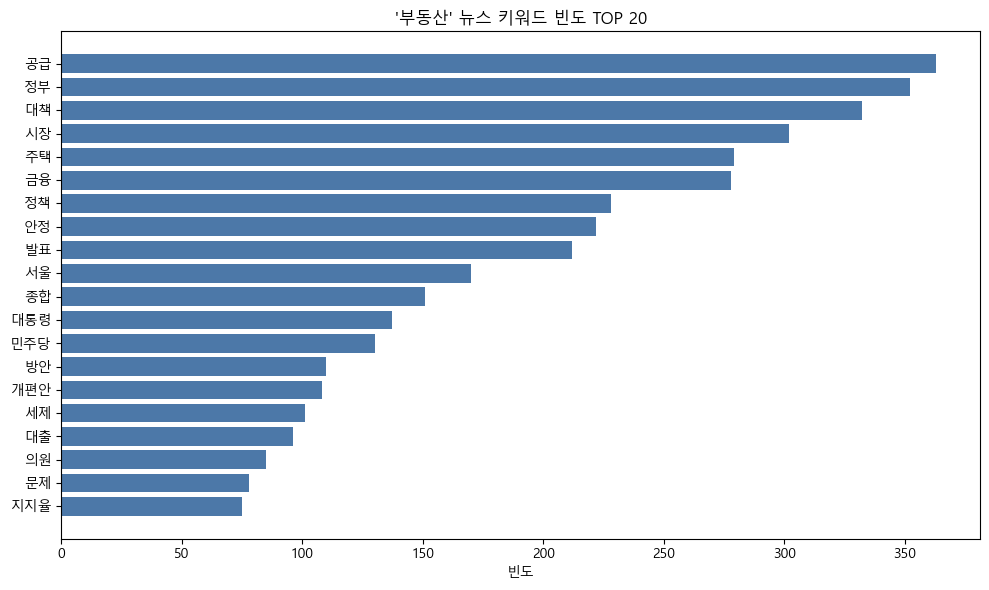

In [14]:
# ─────────────────────────────────────────────────────────────
# [분석1] 키워드 빈도 막대그래프
#   - 가장 많이 나온 단어 20개를 가로 막대그래프로 표시
# ─────────────────────────────────────────────────────────────
words, vals = zip(*cnt.most_common(20))   # 빈도 상위 20개를 (단어들), (빈도들)로 분리
plt.figure(figsize=(10, 6))
# barh: 가로 막대. reversed()로 순서를 뒤집어 1위가 맨 위에 오게 함
plt.barh(list(reversed(words)), list(reversed(vals)), color='#4C78A8')
#plt.barh(list(words), list(vals), color='#4C78A8')
plt.title("'부동산' 뉴스 키워드 빈도 TOP 20")
plt.xlabel('빈도')
plt.tight_layout()                        # 라벨이 잘리지 않게 여백 자동 조정
plt.savefig('freq.png', dpi=120)          # 이미지 파일로 저장
plt.show()

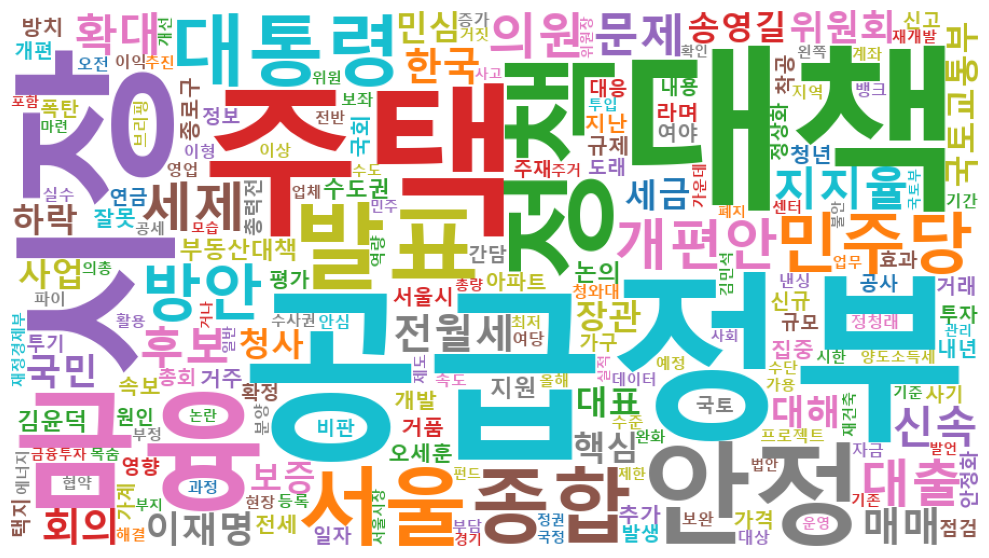

In [15]:
# ─────────────────────────────────────────────────────────────
# [분석2] 워드클라우드
#   - 단어 빈도가 높을수록 크게 그려주는 시각화
#   - 주의: WordCloud는 폰트 '이름'이 아니라 '파일 경로'(font_path)를 받음
# ─────────────────────────────────────────────────────────────
wc = WordCloud(font_path=FONT,            # 한글 폰트 파일 경로
               background_color='white',
               width=900, height=500,
               colormap='tab10'           # 색상 팔레트
               ).generate_from_frequencies(cnt)   # 빈도 딕셔너리로 생성
plt.figure(figsize=(10, 6))
plt.imshow(wc)      # 워드클라우드 이미지 표시
plt.axis('off')     # 축 눈금 숨김
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=120)
plt.show()

노드 수: 18 / 엣지 수: 102


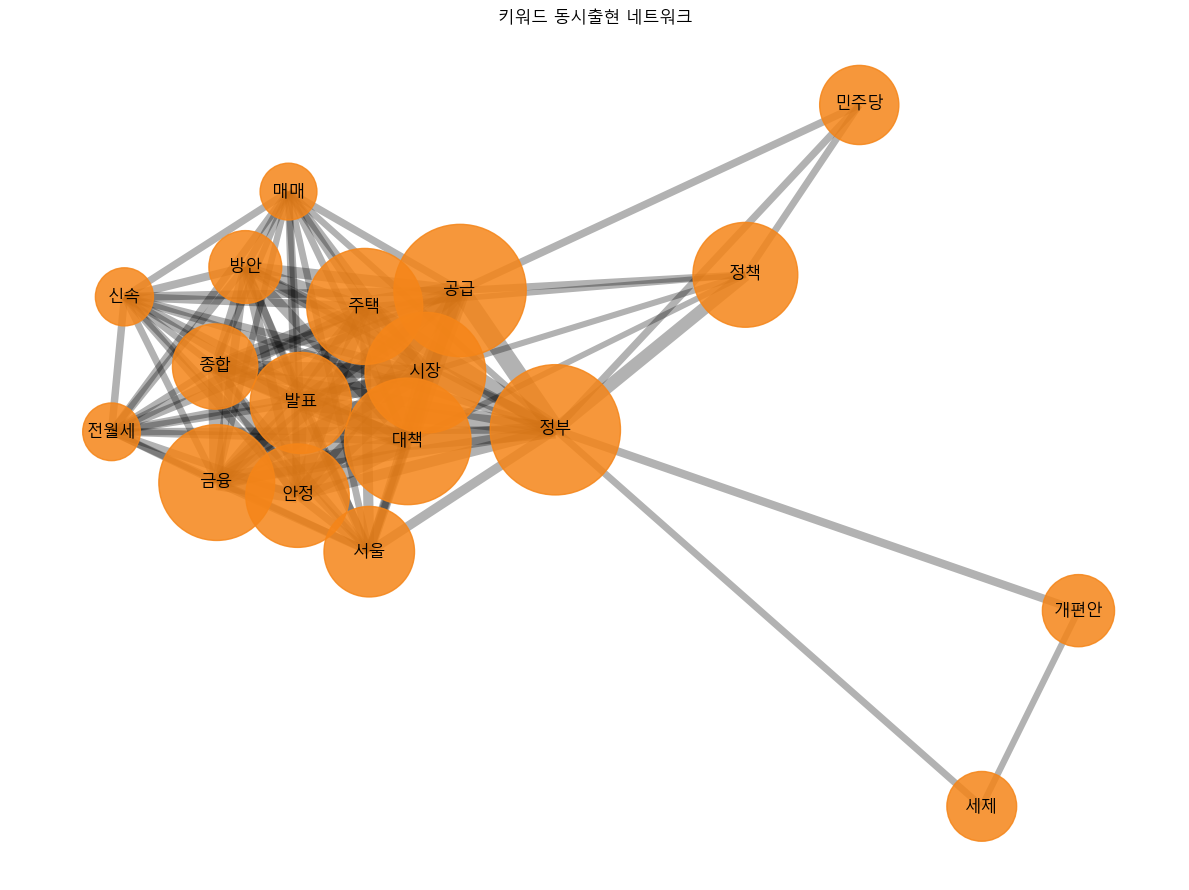

In [16]:
# ─────────────────────────────────────────────────────────────
# [분석3] 연관어(동시출현) 네트워크
#   - '같은 기사에 함께 등장한' 단어 쌍을 세어 관계망으로 그림
#   - 자주 함께 나오는 단어일수록 굵은 선으로 연결됨
#   — 500건 데이터 인 경우에
#     - 데이터가 많을수록 NODE_MIN / EDGE_MIN 을 올려 노드 수를 줄인다
#     - 목표: 노드 30~50개 (print로 확인하며 조절)
# ─────────────────────────────────────────────────────────────

# ── 데이터 양에 맞춰 이 세 숫자만 조절하면 됩니다 ──
NODE_MIN  = 60   # 노드로 쓸 단어의 최소 빈도 (데이터 많을수록 ↑)
EDGE_MIN  = 40   # 선으로 연결할 최소 동시출현 (데이터 많을수록 ↑)
LABEL_TOP = 60   # 라벨(글자)을 달 상위 단어 개수 (노드 수와 비슷하게)

# 1) 같은 기사에 함께 등장한 단어 쌍 세기
pair = Counter()
for lst in news_df['nouns']:
    # 한 기사 안에서 빈도 NODE_MIN 이상인 단어만 골라 중복 제거
    uniq = sorted(set(w for w in lst if cnt[w] >= NODE_MIN))
    for a, b in itertools.combinations(uniq, 2):
        pair[(a, b)] += 1

# 2) EDGE_MIN 이상 함께 등장한 쌍만 선(edge)으로 연결
G = nx.Graph()
for (a, b), c in pair.items():
    if c >= EDGE_MIN:
        G.add_edge(a, b, weight=c)

# 3) 연결이 거의 없는 고립 노드(선 1개 이하) 제거
G.remove_nodes_from([n for n in list(G.nodes()) if G.degree(n) < 2])

# 4) 노드/엣지 개수 확인 → 이 값을 보며 위 두 숫자를 조절
print("노드 수:", G.number_of_nodes(), "/ 엣지 수:", G.number_of_edges())

# 5) 그리기
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=1.2, seed=42)          # k ↑ → 노드 간격 넓어짐

# 노드: 단어 빈도가 클수록 크게
nx.draw_networkx_nodes(G, pos, node_color='#F58518',
                       node_size=[cnt[n] * 25 for n in G.nodes()], alpha=.85)
# 엣지: 동시출현이 많을수록 굵게
nx.draw_networkx_edges(G, pos, alpha=.3,
                       width=[G[u][v]['weight'] * .1 for u, v in G.edges()])

# 라벨: 빈도 상위 LABEL_TOP개 단어에만 표시 (글자 겹침 방지)
big = [n for n, _ in sorted(((n, cnt[n]) for n in G.nodes()),
                            key=lambda x: -x[1])[:LABEL_TOP]]
nx.draw_networkx_labels(G, pos, labels={n: n for n in big}, font_family=FONT_NAME)

plt.title('키워드 동시출현 네트워크')
plt.axis('off')
plt.tight_layout()
plt.savefig('network.png', dpi=120)
plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────
# [분석4] TF-IDF 기사별 핵심어
#   - TF-IDF: 특정 기사에는 자주 나오지만 다른 기사엔 드문 단어에 높은 점수
#   - 단순 빈도와 달리 '그 기사만의 특징어'를 뽑아줌
# ─────────────────────────────────────────────────────────────
# 각 기사의 명사 리스트를 공백으로 이어붙여 하나의 문자열(문서)로 만듦
docs = [' '.join(lst) for lst in news_df['nouns']]

# TfidfVectorizer: 문서들을 TF-IDF 수치 행렬로 변환
#   token_pattern: 한 글자 단어도 토큰으로 인정하도록 패턴 지정
tv = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
M = tv.fit_transform(docs)              # M: (기사 수 × 단어 수) 크기의 TF-IDF 행렬
vocab = tv.get_feature_names_out()      # 열 인덱스에 해당하는 실제 단어 목록

# 앞에서부터 5개 기사에 대해 핵심어 상위 5개씩 출력
for i in range(10):
    row = M[i].toarray()[0]             # i번째 기사의 TF-IDF 점수 배열
    top = row.argsort()[::-1][:5]       # 점수가 높은 순으로 인덱스 정렬 후 상위 5개
    # 점수가 0보다 큰 단어만 '단어(점수)' 형태로 조합
    kw = ', '.join(f"{vocab[j]}({row[j]:.2f})" for j in top if row[j] > 0)
    print(f"[기사{i+1}] {clean(news_df['title'][i])[:30]}\n   핵심어: {kw}")

[기사1] [속보] 이 대통령 "시한폭탄 부동산 문제…가용 수단·
   핵심어: 수단(0.33), 투입(0.33), 가용(0.33), 역량(0.31), 집중(0.29)
[기사2] [속보] 李 대통령 "부동산 공급 총력전 나서야…법·제
   핵심어: 총력전(0.35), 보좌(0.35), 대통령(0.34), 주재(0.33), 회의(0.26)
[기사3] [속보] 이 대통령 "부동산 거품 방치할 수 없는 수준
   핵심어: 사회(0.38), 대통령(0.34), 양극화(0.25), 심화(0.24), 지대(0.23)
[기사4] 오세훈 "부동산대책, 현장 요구 핵심사항들 반영되지 않
   핵심어: 반영(0.43), 사항(0.39), 오세훈(0.32), 요청(0.24), 전향(0.24)
[기사5] 이 대통령 지지율 49%로 취임 후 최저‥부동산 정책,
   핵심어: 응답(0.51), 잘못(0.38), 대해(0.33), 반대(0.26), 비율(0.26)
[기사6] [속보] 李 “부동산 거품 더 방치 못해…잃어버린 20
   핵심어: 거품(0.40), 방치(0.39), 세계(0.28), 민관(0.28), 대통령(0.27)
[기사7] [속보] 이 대통령 “부동산 문제 해결 가용 수단 집중
   핵심어: 집중(0.43), 수단(0.32), 가용(0.32), 투입(0.32), 해결(0.31)
[기사8] 오세훈 “부동산대책 효과 위해, 8·3 세재개편 재검토
   핵심어: 검토(0.43), 효과(0.38), 오세훈(0.32), 발휘(0.27), 발표(0.27)
[기사9] [8·13 부동산대책] 일문일답 "총량규제 3%로 푼다
   핵심어: 잔금(0.40), 대출(0.36), 올해(0.33), 실수(0.32), 일문일답(0.24)
[기사10] 정청래 "김민석, 지난 1년간 부동산 공급 위해 뭘 했
   핵심어: 후보(0.42), 김민석(0.40), 정청래(0.36), 공급(0.30), 지난(0.30)
